In [109]:
import sys
import os
from pathlib import Path

import numpy as np
import math
from functools import partial


In [110]:
path = "C:\josim_projects"
file_in = 'AQFP_TEST'  #input .cir file
file_out = file_in #output .dat and .csv files

os.chdir(path)
os.system(f"josim-cli ./{file_in}.cir -V 1")

<>:1: SyntaxWarning: "\j" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\j"? A raw string is also an option.
<>:1: SyntaxWarning: "\j" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\j"? A raw string is also an option.
C:\Users\Арина\AppData\Local\Temp\ipykernel_1852\463195032.py:1: SyntaxWarning: "\j" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\j"? A raw string is also an option.
  path = "C:\josim_projects"


0

In [111]:
data = np.genfromtxt(f"{file_out}.dat", delimiter=None, skip_header=1)
time = data[:, 0] * 10**12
p_x = data[:, 1]
p_out = data[:, 2]
p_B01 = data[:, 3]
p_B02 = data[:, 4]
print(data.shape) #узнать размер массива

(7999, 5)


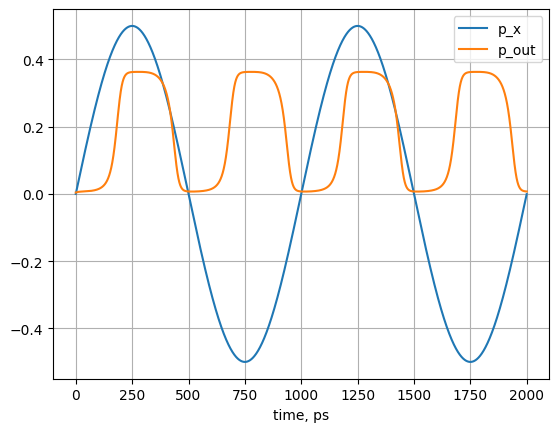

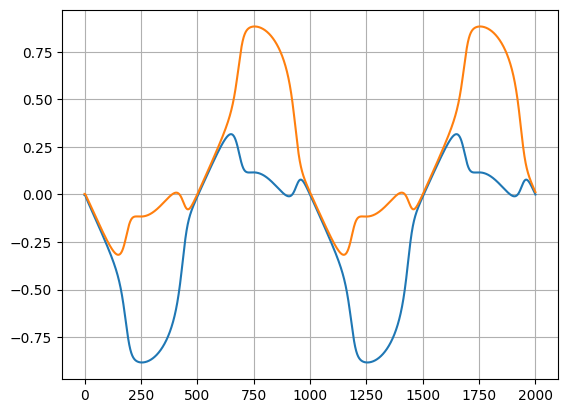

In [112]:
import matplotlib.pyplot as plt
plt.plot(time, p_x / (2*math.pi),label='p_x')
plt.xlabel('time, ps') 
plt.plot(time, p_out / (2*math.pi),label='p_out')
plt.legend()
plt.grid()
plt.show()
plt.plot(time, p_B01 / (2*math.pi))
plt.plot(time, p_B02 / (2*math.pi))
plt.grid()
plt.show()

In [113]:
p_minus = (p_B01-p_B02)/2
p_plus = (p_B01+p_B02)/2 
beta_L = 0.3 # L1
beta_q = 0.3 # Lq
p_in = 0.159 # Iin

idx_max = np.argmax(p_x)
idx_min = np.argmin(p_x)
print(idx_max)
print(idx_min)
idx = 100
p_plus_2d = np.linspace(-np.pi, np.pi, 100)
p_minus_2d = np.linspace(-np.pi, np.pi, 100)
P_plus, P_minus = np.meshgrid(p_plus_2d, p_minus_2d)
p_x_fixed = p_x[idx]

U_qfp_norm = (p_x_fixed - P_minus)**2/beta_L + (p_in - P_plus)**2/(beta_L+2*beta_q) - 2*np.cos(P_minus)*np.cos(P_plus)

999
2999


Text(0.5, 1.0, 'Поверхность потенциальной энергии AQFP')

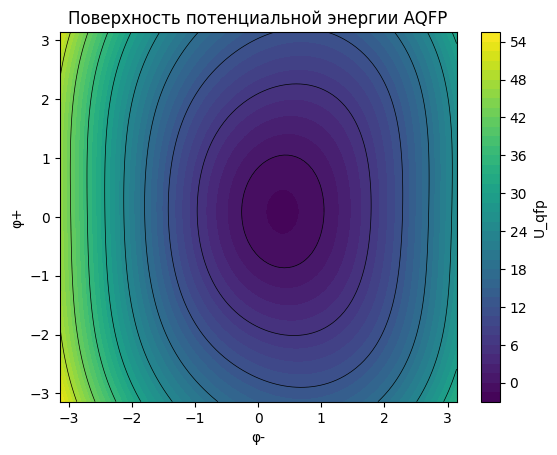

In [114]:

plt.figure()
contour_lines = plt.contour(P_minus,P_plus, U_qfp_norm, levels=10, colors='black', linewidths=0.5)
plt.contourf(P_minus, P_plus, U_qfp_norm, levels=50, cmap='viridis')
plt.colorbar(label='U_qfp')
plt.xlabel('φ-')
plt.ylabel('φ+')
plt.title('Поверхность потенциальной энергии AQFP')